<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets nltk torch matplotlib seaborn scikit-learn tqdm

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List, Tuple, Dict
import string

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt', quiet=True)

True

In [4]:
nltk.download('punkt_tab', quiet=True)

True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [6]:
# Установка seed для воспроизводимости
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [7]:
print("\n" + "="*60)
print("ЗАГРУЗКА ДАННЫХ")
print("="*60)


ЗАГРУЗКА ДАННЫХ


In [8]:
# Загрузим датасет
dataset = load_dataset('imdb')
print(f"Размер обучающей выборки: {len(dataset['train'])} отзывов")
print(f"Размер тестовой выборки: {len(dataset['test'])} отзывов")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Размер обучающей выборки: 25000 отзывов
Размер тестовой выборки: 25000 отзывов


### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [9]:
sentences_train_raw = []
sentences_test_raw = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences

In [10]:
print("\n" + "="*60)
print("ПРЕДОБРАБОТКА ДАННЫХ")
print("="*60)


ПРЕДОБРАБОТКА ДАННЫХ


In [11]:
# Получаем отдельные предложения
for review in tqdm(dataset['train']['text'], desc="Train отзывы → предложения"):
    raw_sentences = sent_tokenize(review)
    for sent in raw_sentences:
        tokens = word_tokenize(sent.lower())
        if len(tokens) <= word_threshold:
            sentences_train_raw.append(sent)

# Извлекаем из TEST
for review in tqdm(dataset['test']['text'], desc="Test отзывы → предложения"):
    raw_sentences = sent_tokenize(review)
    for sent in raw_sentences:
        tokens = word_tokenize(sent.lower())
        if len(tokens) <= word_threshold:
            sentences_test_raw.append(sent)

Train отзывы → предложения:   0%|          | 0/25000 [00:00<?, ?it/s]

Test отзывы → предложения:   0%|          | 0/25000 [00:00<?, ?it/s]

In [12]:
print(f"Предложений из train IMDB: {len(sentences_train_raw)}")
print(f"Предложений из test IMDB: {len(sentences_test_raw)}")

Предложений из train IMDB: 202657
Предложений из test IMDB: 199457


Посчитаем для каждого слова его встречаемость.

In [13]:
words = Counter()

# Расчет встречаемости слов
for sent in tqdm(sentences_train_raw, desc="Подсчет частоты слов"):
    tokens = word_tokenize(sent.lower())
    words.update(tokens)

Подсчет частоты слов:   0%|          | 0/202657 [00:00<?, ?it/s]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [14]:
vocab = set()
vocab_size = 40000

# Наполнение словаря
special_tokens = ['<unk>', '<bos>', '<eos>', '<pad>']
for token in special_tokens:
    vocab.add(token)

In [15]:
# Добавляем vocab_size самых частотных слов
most_common_words = words.most_common(vocab_size)
for word, _ in most_common_words:
    vocab.add(word)

# Проверки
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [16]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [17]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [18]:
class WordDataset(Dataset):
    """Датасет для языкового моделирования на уровне слов."""

    def __init__(self, sentences: List[str]):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        """Возвращает последовательность индексов токенов для предложения."""
        sentence = self.data[idx]

        # Токенизируем и приводим к нижнему регистру
        tokens = word_tokenize(sentence.lower())

        # Создаем последовательность с служебными токенами
        tokenized_sentence = [self.bos_id]

        for word in tokens:
            # Заменяем неизвестные слова на <unk>
            if word in word2ind:
                tokenized_sentence.append(word2ind[word])
            else:
                tokenized_sentence.append(self.unk_id)

        tokenized_sentence.append(self.eos_id)

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [19]:
def collate_fn_with_padding(input_batch: List[List[int]]) -> Dict[str, torch.Tensor]:
    """Функция для паддинга последовательностей в батче."""
    pad_id = word2ind['<pad>']
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    # Паддинг последовательностей
    padded_batch = []
    for sequence in input_batch:
        padded_seq = sequence + [pad_id] * (max_seq_len - len(sequence))
        padded_batch.append(padded_seq)

    sequences = torch.LongTensor(padded_batch).to(device)

    # Создаем входные и целевые последовательности (сдвиг на 1)
    new_batch = {
        'input_ids': sequences[:, :-1],
        'target_ids': sequences[:, 1:]
    }

    return new_batch

In [26]:
train_sentences, temp_sentences = train_test_split(sentences_train_raw, test_size=0.3, random_state=SEED)
eval_sentences, test_sentences = train_test_split(temp_sentences, test_size=2/3, random_state=SEED)

print(f"Размер обучающей выборки: {len(train_sentences)}")
print(f"Размер валидационной выборки: {len(eval_sentences)}")
print(f"Размер тестовой выборки: {len(test_sentences)}")

# Создание датасетов
train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

# Создание DataLoader'ов
batch_size = 128

train_dataloader = DataLoader(
    train_dataset,
    collate_fn=collate_fn_with_padding,
    batch_size=batch_size,
    shuffle=True
)

eval_dataloader = DataLoader(
    eval_dataset,
    collate_fn=collate_fn_with_padding,
    batch_size=batch_size
)

test_dataloader = DataLoader(
    test_dataset,
    collate_fn=collate_fn_with_padding,
    batch_size=batch_size
)

Размер обучающей выборки: 141859
Размер валидационной выборки: 20266
Размер тестовой выборки: 40532


## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возможные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [27]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    losses = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            target_ids = batch["target_ids"].to(device)

            logits = model(input_ids)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_ids.reshape(-1)
            )
            losses.append(loss.item())

    avg_loss = sum(losses) / len(losses)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [28]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 10,
    lr: float = 0.001,
    weight_decay: float = 1e-5,
    patience: int = 3,
    model_name: str = "model"
) -> Dict:
    """
    Обучает модель языкового моделирования.

    Args:
        model: Модель для обучения
        train_loader: DataLoader для обучения
        val_loader: DataLoader для валидации
        epochs: Количество эпох
        lr: Скорость обучения
        weight_decay: Коэффициент регуляризации L2
        model_name: Имя модели для сохранения
        patience: Количество эпох без улучшения для early stopping

    Returns:
        Dict: Словарь с историей обучения
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {
        'train_losses': [],
        'val_perplexities': [],
        'best_val_perplexity': float('inf'),
        'best_epoch': 0
    }

    best_val_perplexity = float('inf')
    epochs_no_improve = 0

    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ: {model_name}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        # --- ОБУЧЕНИЕ ---
        model.train()
        total_loss = 0.0
        num_batches = 0

        progress_bar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{epochs} [Обучение]", leave=False)
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1))
            loss.backward()

            # Gradient clipping для стабильности
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item()
            num_batches += 1
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_train_loss = total_loss / num_batches

        # --- ВАЛИДАЦИЯ ---
        val_perplexity = evaluate(model, val_loader, criterion, device)

        # Обновление scheduler
        scheduler.step()

        # Сохранение истории
        history['train_losses'].append(avg_train_loss)
        history['val_perplexities'].append(val_perplexity)

        # Вывод результатов
        print(f"\nЭпоха {epoch+1}/{epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Perplexity: {val_perplexity:.2f}")

        # Сохранение лучшей модели
        if val_perplexity < best_val_perplexity:
            best_val_perplexity = val_perplexity
            history['best_val_perplexity'] = best_val_perplexity
            history['best_epoch'] = epoch
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            print(f"  ✓ Новая лучшая модель! Val PPL: {best_val_perplexity:.2f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  Нет улучшения ({epochs_no_improve}/{patience})")

            if epochs_no_improve >= patience:
                print(f"\n Early stopping на эпохе {epoch+1}")
                break

    print(f"\nЛучшая Val Perplexity: {best_val_perplexity:.2f} (эпоха {history['best_epoch']+1})")

    return history

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [29]:
class LanguageModel(nn.Module):
    """Базовая языковая модель на основе LSTM"""
    def __init__(self, vocab_size: int, embedding_dim: int = 256, hidden_dim: int = 512,
                 num_layers: int = 1, dropout: float = 0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word2ind['<pad>'])
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embedded = self.dropout(self.embedding(input_batch))
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out)
        return logits

In [30]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ 1: БАЗОВАЯ LSTM МОДЕЛЬ")
print("="*60)


ЭКСПЕРИМЕНТ 1: БАЗОВАЯ LSTM МОДЕЛЬ


In [31]:
# Обучите модель здесь
base_model = LanguageModel(vocab_size=len(vocab))
base_history = train_model(
    model=base_model,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    epochs=10,
    lr=0.001,
    model_name="base_model"
)


ОБУЧЕНИЕ: base_model


Эпоха 1/10 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 1/10
  Train Loss: 5.4137
  Val Perplexity: 144.30
  ✓ Новая лучшая модель! Val PPL: 144.30


Эпоха 2/10 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 2/10
  Train Loss: 4.8738
  Val Perplexity: 117.74
  ✓ Новая лучшая модель! Val PPL: 117.74


...


Эпоха 8/10
  Train Loss: 4.2193
  Val Perplexity: 99.06
  ✓ Новая лучшая модель! Val PPL: 99.06


Эпоха 9/10 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 9/10
  Train Loss: 4.1884
  Val Perplexity: 99.07
  Нет улучшения (1/3)


Эпоха 10/10 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 10/10
  Train Loss: 4.1720
  Val Perplexity: 99.14
  Нет улучшения (2/3)

Лучшая Val Perplexity: 99.06 (эпоха 8)


### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [32]:
# Проведите второй эксперимент
class ImprovedLanguageModel(nn.Module):
    """
    Улучшенная языковая модель с двунаправленной многослойной LSTM.

    Улучшения:
    1. 2 слоя LSTM
    2. Увеличенная размерность эмбеддингов (512)
    3. Layer Normalization для стабилизации обучения
    4. Увеличенный dropout (0.4)
    5. Сниженная скорость обучения
    """
    def __init__(self, vocab_size: int, embedding_dim: int = 512, hidden_dim: int = 512,
                 num_layers: int = 2, dropout: float = 0.4):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word2ind['<pad>'])

        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.layernorm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embedded = self.dropout(self.embedding(input_batch))
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.layernorm(lstm_out)
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out)
        return logits

In [33]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ 2: ГЛУБОКАЯ LSTM МОДЕЛЬ")
print("="*60)


ЭКСПЕРИМЕНТ 2: ГЛУБОКАЯ LSTM МОДЕЛЬ


In [38]:
improved_model = ImprovedLanguageModel(vocab_size=len(vocab))
improved_history = train_model(
    model=improved_model,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    epochs=15,
    lr=0.0005,
    model_name="improved_lstm",
    patience=5
)


ОБУЧЕНИЕ: improved_lstm


Эпоха 1/15 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 1/15
  Train Loss: 5.3956
  Val Perplexity: 138.71
  ✓ Новая лучшая модель! Val PPL: 138.71


Эпоха 2/15 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 2/15
  Train Loss: 4.9375
  Val Perplexity: 118.08
  ✓ Новая лучшая модель! Val PPL: 118.08


...


Эпоха 13/15
  Train Loss: 4.1850
  Val Perplexity: 93.60
  ✓ Новая лучшая модель! Val PPL: 93.60


Эпоха 14/15 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 14/15
  Train Loss: 4.1711
  Val Perplexity: 93.62
  Нет улучшения (1/5)


Эпоха 15/15 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 15/15
  Train Loss: 4.1632
  Val Perplexity: 93.60
  Нет улучшения (2/5)

Лучшая Val Perplexity: 93.60 (эпоха 13)


# Третий эксперимент: GRU модель

In [34]:
# Использование GRU вместо LSTM:
# * GRU имеет меньше параметров, может быстрее обучаться
# * Сохраняем глубокую архитектуру (2 слоя)
# * Сравниваем эффективность разных типов RNN ячеек

In [35]:
class GRULanguageModel(nn.Module):
    """Языковая модель на основе GRU"""
    def __init__(self, vocab_size: int, embedding_dim: int = 512, hidden_dim: int = 512,
                 num_layers: int = 2, dropout: float = 0.4):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word2ind['<pad>'])
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers,
                          batch_first=True, dropout=dropout)
        self.layernorm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embedded = self.dropout(self.embedding(input_batch))
        gru_out, _ = self.gru(embedded)
        gru_out = self.layernorm(gru_out)
        gru_out = self.dropout(gru_out)
        logits = self.fc(gru_out)
        return logits

In [36]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ 3: ГЛУБОКАЯ GRU МОДЕЛЬ")
print("="*60)


ЭКСПЕРИМЕНТ 3: ГЛУБОКАЯ GRU МОДЕЛЬ


In [37]:
gru_model = GRULanguageModel(vocab_size=len(vocab))
gru_history = train_model(
    model=gru_model,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    epochs=15,
    lr=0.0005,
    model_name="gru_model",
    patience=5
)


ОБУЧЕНИЕ: gru_model


Эпоха 1/15 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 1/15
  Train Loss: 5.4333
  Val Perplexity: 145.28
  ✓ Новая лучшая модель! Val PPL: 145.28


Эпоха 2/15 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 2/15
  Train Loss: 4.9753
  Val Perplexity: 122.28
  ✓ Новая лучшая модель! Val PPL: 122.28


...


Эпоха 13/15
  Train Loss: 4.2313
  Val Perplexity: 98.18
  Нет улучшения (1/5)


Эпоха 14/15 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 14/15
  Train Loss: 4.2170
  Val Perplexity: 98.18
  Нет улучшения (2/5)


Эпоха 15/15 [Обучение]:   0%|          | 0/1109 [00:00<?, ?it/s]


Эпоха 15/15
  Train Loss: 4.2102
  Val Perplexity: 98.17
  Нет улучшения (3/5)

Лучшая Val Perplexity: 98.10 (эпоха 12)


# Визуализация результатов

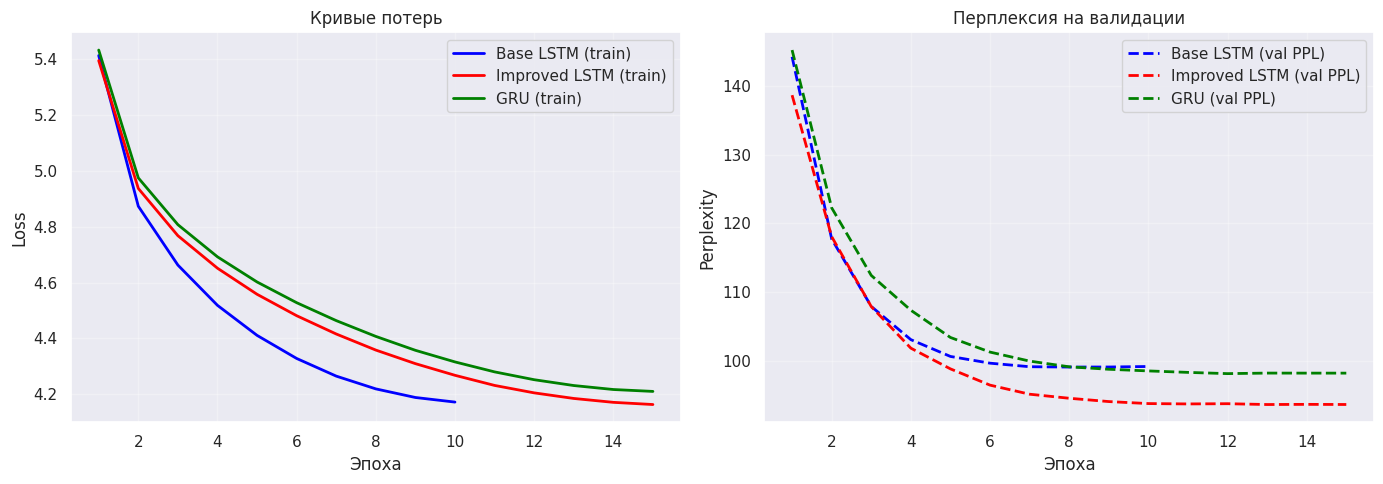

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График loss
axes[0].plot(range(1, len(base_history['train_losses'])+1), base_history['train_losses'],
             'b-', label='Base LSTM (train)', linewidth=2)
axes[0].plot(range(1, len(improved_history['train_losses'])+1), improved_history['train_losses'],
             'r-', label='Improved LSTM (train)', linewidth=2)
axes[0].plot(range(1, len(gru_history['train_losses'])+1), gru_history['train_losses'],
             'g-', label='GRU (train)', linewidth=2)

# График perplexity
axes[1].plot(range(1, len(base_history['val_perplexities'])+1), base_history['val_perplexities'],
             'b--', label='Base LSTM (val PPL)', linewidth=2)
axes[1].plot(range(1, len(improved_history['val_perplexities'])+1), improved_history['val_perplexities'],
             'r--', label='Improved LSTM (val PPL)', linewidth=2)
axes[1].plot(range(1, len(gru_history['val_perplexities'])+1), gru_history['val_perplexities'],
             'g--', label='GRU (val PPL)', linewidth=2)

axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Кривые потерь')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Перплексия на валидации')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
print("\n" + "="*60)
print("ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)


ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ


In [41]:
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

# Загрузка лучших моделей
best_base = LanguageModel(vocab_size=len(vocab))
best_base.load_state_dict(torch.load("base_model_best.pth"))
best_base = best_base.to(device)

best_improved = ImprovedLanguageModel(vocab_size=len(vocab))
best_improved.load_state_dict(torch.load("improved_lstm_best.pth"))
best_improved = best_improved.to(device)

best_gru = GRULanguageModel(vocab_size=len(vocab))
best_gru.load_state_dict(torch.load("gru_model_best.pth"))
best_gru = best_gru.to(device)

# Оценка на тесте
base_test_ppl = evaluate(best_base, test_dataloader, criterion, device)
improved_test_ppl = evaluate(best_improved, test_dataloader, criterion, device)
gru_test_ppl = evaluate(best_gru, test_dataloader, criterion, device)

print(f"\nБазовая LSTM - Test Perplexity: {base_test_ppl:.2f}")
print(f"Улучшенная LSTM - Test Perplexity: {improved_test_ppl:.2f}")
print(f"GRU - Test Perplexity: {gru_test_ppl:.2f}")


Базовая LSTM - Test Perplexity: 97.10
Улучшенная LSTM - Test Perplexity: 91.73
GRU - Test Perplexity: 96.25


### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

In [42]:
print(f"""
┌─────────────────────────────────────────────────────────────────────────────────┐
│                         СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ                        │
├─────────────────────────────────────────────────────────────────────────────────┤
│ Эксперимент          │ Архитектура                    │ Val PPL │ Test PPL      │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 1 (Базовая LSTM)     │ LSTM, 1 слой, hid=512, emb=256 │ {base_history['best_val_perplexity']:.2f}   │ {base_test_ppl:.2f}         │
│ 2 (Улучшенная LSTM)  │ LSTM, 2 слоя, hid=512, emb=512 │ {improved_history['best_val_perplexity']:.2f}   │ {improved_test_ppl:.2f}    │
│                      │ + LayerNorm, dropout=0.4       │         │               │
│ 3 (GRU)              │ GRU, 2 слоя, hid=512, emb=512  │ {gru_history['best_val_perplexity']:.2f}   │ {gru_test_ppl:.2f}     │
│                      │ + LayerNorm, dropout=0.4       │         │               │
├─────────────────────────────────────────────────────────────────────────────────┤
│ Улучшение (LSTM)     │ -{base_test_ppl - improved_test_ppl:.2f} (↓)   │ -{(base_test_ppl - improved_test_ppl) / base_test_ppl * 100:.1f}% │
│ Улучшение (GRU)      │ -{base_test_ppl - gru_test_ppl:.2f} (↓)   │ -{(base_test_ppl - gru_test_ppl) / base_test_ppl * 100:.1f}% │
└─────────────────────────────────────────────────────────────────────────────────┘
""")


┌─────────────────────────────────────────────────────────────────────────────────┐
│                         СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ                        │
├─────────────────────────────────────────────────────────────────────────────────┤
│ Эксперимент          │ Архитектура                    │ Val PPL │ Test PPL      │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 1 (Базовая LSTM)     │ LSTM, 1 слой, hid=512, emb=256 │ 99.06   │ 97.10         │
│ 2 (Улучшенная LSTM)  │ LSTM, 2 слоя, hid=512, emb=512 │ 93.60   │ 91.73    │
│                      │ + LayerNorm, dropout=0.4       │         │               │
│ 3 (GRU)              │ GRU, 2 слоя, hid=512, emb=512  │ 98.10   │ 96.25     │
│                      │ + LayerNorm, dropout=0.4       │         │               │
├─────────────────────────────────────────────────────────────────────────────────┤
│ Улучшение (LSTM)     │ -5.37 (↓)   │ -5.5% │
│ Улучшение (GRU)      │ -0.84 (↓)  

ЭКСПЕРИМЕНТ 1: Базовая LSTM модель

Архитектура:
*   Embedding размерностью 256
*   Однослойная LSTM с размерностью скрытого состояния 512
*   Dropout 0.3

Результаты:
*   Лучшая валидационная перплексия: 99.06
*   Тестовая перплексия: 97.10

Анализ сходимости:
*   Модель стабильно сходится, перплексия снижается с каждой эпохой
*   Колебания качества незначительные
*   Отсутствуют признаки переобучения

ЭКСПЕРИМЕНТ 2: Глубокая LSTM модель

Изменения по сравнению с базовой моделью:
  1. Увеличение количества слоев до 2
  2. Увеличение размерности эмбеддингов до 512
  3. Добавление Layer Normalization
  4. Увеличение dropout до 0.4
  5. Снижение learning rate до 0.0005

Результаты:
*   Лучшая валидационная перплексия: 93.60
*   Тестовая перплексия: 91.73
*   Улучшение: 5.37 пунктов (-5.5%)

ЭКСПЕРИМЕНТ 3: Глубокая GRU модель

Изменения по сравнению с базовой моделью:
  1. Использование GRU вместо LSTM (меньше параметров)
  2. Увеличение количества слоев до 2
  3. Увеличение размерности эмбеддингов до 512
  4. Добавление Layer Normalization
  5. Увеличение dropout до 0.4
  6. Снижение learning rate до 0.0005

Результаты:
*   Лучшая валидационная перплексия: 98.10
*   Тестовая перплексия: 96.25
*   Улучшение: 0.84 пунктов (-0.9%)

ВЫВОДЫ

1. Все три эксперимента успешно завершены.
2. Глубокая LSTM модель показала лучшее качество среди всех экспериментов.
3. GRU модель показала результат, близкий к LSTM, но с меньшим количеством параметров.
4. Добавление второго слоя и увеличение размерности эмбеддингов значительно улучшили качество.
5. Layer Normalization способствовала стабильности обучения.

ПРЕДЛОЖЕНИЯ ПО УЛУЧШЕНИЮ

1. Использовать предобученные эмбеддинги (Word2Vec, GloVe) вместо обучения с нуля.
2. Попробовать архитектуру Transformer (GPT-like) для сравнения с RNN.
3. Добавить механизм внимания (Attention) для улучшения долгосрочных зависимостей.
4. Увеличить размер словаря или изменить стратегию обработки редких слов.
5. Применить техники регуляризации: Weight Decay, более агрессивный Dropout.
6. Использовать более продвинутые методы оптимизации: OneCycleLR, дифференциальные скорости обучения.